# Sekcja 1: Setup
* Importy
* Definicje parametrów
* Funkcje generujące dane:
    * Funkcja budująca macierz $A$
    * Funkcja generująca wektor referencyjny $X_ref$
    * Funkcja obliczająca wektor $B$
* Funkcja normy maksimum

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

# Globalne ziarno losowości dla całego notebooka
RANDOM_SEED = 27052026

# Stałe globalne zdefiniowane w zadaniu
K_CONST = 8
M_CONST = 1.5

print(f"Środowisko skonfigurowane. Globalny seed: {RANDOM_SEED}")

Środowisko skonfigurowane. Globalny seed: 27052026


In [30]:
def generate_matrix_A(n, k=K_CONST, m=M_CONST):
    """
    Generuje macierz A o rozmiarze n x n zgodnie z wariantem c (indeksowanie 1-based).
    """
    A = np.zeros((n, n), dtype=np.float64)
    
    for i in range(n):
        for j in range(n):
            if i == j:
                A[i, j] = k
            elif j > i:
                math_j = j + 1
                A[i, j] = ((-1) ** math_j) * m / math_j
            elif j == i - 1:
                math_i = i + 1
                A[i, j] = m / math_i
            
    return A

def generate_x_ref(n, seed=RANDOM_SEED):
    """
    Generuje wektor referencyjny X jako n-elementowy wektor 
    losowych wartości -1 lub 1. Zapewnia identyczny wynik za każdym razem.
    """
    local_rng = np.random.default_rng(seed)
    return local_rng.choice([-1.0, 1.0], size=n)

def generate_b(A, x_ref):
    """
    Oblicza wektor wyrazów wolnych B = A * X_ref.
    """
    return A @ x_ref

def norm_max(vector):
    """
    Oblicza normę maksimum (L_infinity) dla zadanego wektora.
    """
    return np.max(np.abs(vector))

In [31]:
# Testujemy dla małego wymiaru n=3
A_test = generate_matrix_A(3)
x_ref_test = generate_x_ref(3)
b_test = generate_b(A_test, x_ref_test)

print("--- TEST GENEROWANIA MACIERZY (n=3) ---")
print("Macierz A:\n", A_test)
print("\nWektor X_ref:", x_ref_test)
print("\nWektor wyrazów wolnych B:", b_test)

--- TEST GENEROWANIA MACIERZY (n=3) ---
Macierz A:
 [[ 8.    0.75 -0.5 ]
 [ 0.75  8.   -0.5 ]
 [ 0.    0.5   8.  ]]

Wektor X_ref: [-1.  1. -1.]

Wektor wyrazów wolnych B: [-6.75  7.75 -7.5 ]


# Sekcja 2: Implementacja algorytmów
* Główna funkcja metody Jacobiego: Jedna uniwersalna funkcja przyjmująca jako argument typ kryterium stopu (przyrostowe / rezydualne), wektor startowy $X^{(0)}$, tolerancję $\epsilon$ oraz maksymalną liczbę iteracji. Zwraca: wyliczony wektor $X$, liczbę wykonanych iteracji oraz historię błędów do wykresów.
* Funkcja wyznaczania promienia spektralnego: Metoda potęgowa lub funkcja biblioteczna obliczająca $\rho(M)$ dla danej macierzy układu.

In [32]:
def jacobi_method(A, b, x_0, epsilon, criterion='incremental', max_iter=10000):
    """
    Rozwiązuje układ równań Ax = b metodą Jacobiego.
    
    Parametry:
    A         : macierz współczynników (n x n)
    b         : wektor wyrazów wolnych (n)
    x_0       : wektor początkowy (n)
    epsilon   : tolerancja (próg zatrzymania)
    criterion : 'incremental' (przyrostowe) lub 'residual' (rezydualne)
    max_iter  : maksymalna liczba iteracji (zabezpieczenie przed nieskończoną pętlą)
    
    Zwraca:
    x         : wyznaczone rozwiązanie
    iters     : liczba wykonanych iteracji
    history   : lista wartości błędów w kolejnych iteracjach
    """
    # Wyciągamy przekątną macierzy A
    D_diag = np.diag(A)
    
    # Tworzymy macierz (L + U) poprzez wyzerowanie przekątnej w macierzy A
    LU = A - np.diag(D_diag)
    
    # Inicjalizacja wektorów
    x_old = x_0.copy()
    history = []
    
    for iters in range(1, max_iter + 1):
        # Wzór macierzowy Jacobiego (wektoryzacja w NumPy)
        x_new = (b - LU @ x_old) / D_diag
        
        # Wybór i obliczenie błędu zgodnie z zadanym kryterium
        if criterion == 'incremental':
            # || x^(i+1) - x^(i) || < epsilon
            error = norm_max(x_new - x_old)
        elif criterion == 'residual':
            # || A * x^(i) - b || < epsilon 
            error = norm_max(A @ x_new - b)
        else:
            raise ValueError("Nieznane kryterium stopu. Wybierz 'incremental' lub 'residual'.")
        
        # Zapisujemy błąd do historii (przydatne do wykresów)
        history.append(error)
        
        # Warunek stopu
        if error < epsilon:
            return x_new, iters, history
        
        # Przygotowanie do kolejnej iteracji
        x_old = x_new.copy()
        
    print(f"Ostrzeżenie: Osiągnięto maksymalną liczbę iteracji ({max_iter}) bez zbieżności!")
    return x_new, max_iter, history

In [33]:
# Generujemy testowy układ dla n = 5
n_test = 5
A_t = generate_matrix_A(n_test)
x_ref_t = generate_x_ref(n_test)
b_t = generate_b(A_t, x_ref_t)

# Jako wektor początkowy x_0 przyjmujemy same zera
x_0_t = np.zeros(n_test)
eps_t = 1e-6

print("--- TEST URUCHOMIENIA METODY JACOBIEGO ---")

# Test kryterium przyrostowego
x_inc, iters_inc, hist_inc = jacobi_method(A_t, b_t, x_0_t, eps_t, criterion='incremental')
final_err_inc = norm_max(x_inc - x_ref_t)
print(f"[Kryterium przyrostowe] Liczba iteracji: {iters_inc}, Rzeczywisty błąd: {final_err_inc:.2e}")

# Test kryterium rezydualnego
x_res, iters_res, hist_res = jacobi_method(A_t, b_t, x_0_t, eps_t, criterion='residual')
final_err_res = norm_max(x_res - x_ref_t)
print(f"[Kryterium rezydualne]  Liczba iteracji: {iters_res}, Rzeczywisty błąd: {final_err_res:.2e}")

--- TEST URUCHOMIENIA METODY JACOBIEGO ---
[Kryterium przyrostowe] Liczba iteracji: 7, Rzeczywisty błąd: 7.70e-08
[Kryterium rezydualne]  Liczba iteracji: 7, Rzeczywisty błąd: 7.70e-08


# Eksperymenty numeryczne

### Eksperyment 1: Wpływ rozmiaru układu ($n$) na czas i iteracje (Zadanie 1)
* Cel: Porównanie wydajności obu kryteriów stopu dla rosnącej skali problemu.
* Stałe parametry: $\epsilon = 10^{-6}$, $X^{(0)} = \text{losowa permutacja}$.
* Zmienna: Rozmiar macierzy $n \in \{10, 50, 100, 200, 500\}$.
* Procedura: Dla każdego $n$ generujemy układ, a następnie rozwiązujemy go dwukrotnie: najpierw kryterium przyrostowym, potem rezydualnym.
* Mierzone metryki: Czas wykonania, liczba iteracji, ostateczny błąd bezwzględny względem $X_{ref}$.

In [37]:
# Słownik/lista na zebrane dane
experiment_1_data = []

n_sizes = [10, 30, 50, 80, 100, 150, 200, 250, 300, 350, 400, 450, 500]
EPSILON_EXP1 = 1e-6

# Automatyczne tworzenie struktury katalogów wyjściowych
os.makedirs('output/data', exist_ok=True)

print("Uruchamianie Eksperymentu 1...")

for n in n_sizes:
    # 1. Generowanie układu równań
    A = generate_matrix_A(n)
    x_ref = generate_x_ref(n)
    b = generate_b(A, x_ref)
    
    # 2. Generowanie losowego wektora początkowego X^(0) 
    # Używamy unikalnego, ale powtarzalnego seedu dla każdego rozmiaru n
    rng_init = np.random.default_rng(RANDOM_SEED + n)
    x_0 = rng_init.uniform(-2.0, 2.0, size=n) 
    
    # 3. Test kryterium przyrostowego
    start_inc = time.perf_counter()
    x_inc, iters_inc, _ = jacobi_method(A, b, x_0, EPSILON_EXP1, criterion='incremental')
    end_inc = time.perf_counter()
    time_inc = end_inc - start_inc
    err_inc = norm_max(x_inc - x_ref)
    
    # 4. Test kryterium rezydualnego
    start_res = time.perf_counter()
    x_res, iters_res, _ = jacobi_method(A, b, x_0, EPSILON_EXP1, criterion='residual')
    end_res = time.perf_counter()
    time_res = end_res - start_res
    err_res = norm_max(x_res - x_ref)
    
    # 5. Zapisanie wyników do listy
    experiment_1_data.append({
        'Rozmiar n': n,
        'Kryterium': 'przyrostowe',
        'Liczba iteracji': iters_inc,
        'Czas [s]': time_inc,
        'Błąd rzeczywisty': err_inc
    })
    experiment_1_data.append({
        'Rozmiar n': n,
        'Kryterium': 'rezydualne',
        'Liczba iteracji': iters_res,
        'Czas [s]': time_res,
        'Błąd rzeczywisty': err_res
    })

# Konwersja do DataFrame i wyświetlenie tabeli wyników
df_exp1 = pd.DataFrame(experiment_1_data)

# Zapis wyników do pliku CSV
csv_path = 'output/data/experiment_1.csv'
df_exp1.to_csv(csv_path, index=False)

print(f"Eksperyment 1 zakończony. Dane zapisano do: {csv_path}")
df_exp1.head() # Wyświetlamy nagłówek tabeli dla sprawdzenia

Uruchamianie Eksperymentu 1...
Eksperyment 1 zakończony. Dane zapisano do: output/data/experiment_1.csv


,Rozmiar n,Kryterium,Liczba iteracji,Czas [s],Błąd rzeczywisty
0,10,przyrostowe,8,0.000251,8.759988e-09
1,10,rezydualne,7,0.000096,7.160941e-08
2,30,przyrostowe,7,0.000413,3.410267e-08
3,30,rezydualne,7,0.000127,3.410267e-08
4,50,przyrostowe,8,0.000145,1.525189e-08


### Eksperyment 2: Wpływ zadanej dokładności ($\epsilon$) na zbieżność (Zadanie 1)
* Cel: Zbadanie, jak głęboko możemy "dokopać się" z dokładnością i ile nas to kosztuje.
* Stałe parametry: Ustalone średnie $n$ (np. $n = 100$), $X^{(0)} = \text{losowa permutacja}$.
* Zmienna: Tolerancja $\epsilon \in \{10^{-3}, 10^{-5}, 10^{-7}, 10^{-9}, 10^{-12}\}$.
* Procedura: Uruchomienie algorytmu dla obu kryteriów stopu dla malejących wartości $\epsilon$.
* Mierzone metryki: Liczba iteracji, końcowy błąd rzeczywisty $\|X_{obliczone} - X_{ref}\|_\infty$.

In [39]:
import os

# Słownik/lista na zebrane dane
experiment_2_data = []

# Stały rozmiar układu dla tego eksperymentu
N_EXP2 = 100

# Gęste próbkowanie wartości epsilon (tolerancji błędu)
epsilons = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]

# Generowanie stałego układu równań dla całego eksperymentu 2
A_exp2 = generate_matrix_A(N_EXP2)
x_ref_exp2 = generate_x_ref(N_EXP2)
b_exp2 = generate_b(A_exp2, x_ref_exp2)

# Stały, losowy wektor początkowy X^(0)
rng_init_exp2 = np.random.default_rng(RANDOM_SEED + N_EXP2)
x_0_exp2 = rng_init_exp2.uniform(-2.0, 2.0, size=N_EXP2)

print(f"Uruchamianie Eksperymentu 2 dla n = {N_EXP2}...")

for eps in epsilons:
    # 1. Test kryterium przyrostowego
    start_inc = time.perf_counter()
    x_inc, iters_inc, _ = jacobi_method(A_exp2, b_exp2, x_0_exp2, eps, criterion='incremental')
    end_inc = time.perf_counter()
    time_inc = end_inc - start_inc
    err_inc = norm_max(x_inc - x_ref_exp2)
    
    # 2. Test kryterium rezydualnego
    start_res = time.perf_counter()
    x_res, iters_res, _ = jacobi_method(A_exp2, b_exp2, x_0_exp2, eps, criterion='residual')
    end_res = time.perf_counter()
    time_res = end_res - start_res
    err_res = norm_max(x_res - x_ref_exp2)
    
    # 3. Zapisanie wyników do listy
    experiment_2_data.append({
        'Epsilon': eps,
        'Kryterium': 'przyrostowe',
        'Liczba iteracji': iters_inc,
        'Czas [s]': time_inc,
        'Błąd rzeczywisty': err_inc
    })
    experiment_2_data.append({
        'Epsilon': eps,
        'Kryterium': 'rezydualne',
        'Liczba iteracji': iters_res,
        'Czas [s]': time_res,
        'Błąd rzeczywisty': err_res
    })

# Konwersja do DataFrame i zapis do pliku CSV
df_exp2 = pd.DataFrame(experiment_2_data)
csv_path_exp2 = 'output/data/experiment_2.csv'
df_exp2.to_csv(csv_path_exp2, index=False)

print(f"Eksperyment 2 zakończony. Dane zapisano do: {csv_path_exp2}")
df_exp2.head()

Uruchamianie Eksperymentu 2 dla n = 100...
Eksperyment 2 zakończony. Dane zapisano do: output/data/experiment_2.csv


,Epsilon,Kryterium,Liczba iteracji,Czas [s],Błąd rzeczywisty
0,0.00100,przyrostowe,5,0.000176,1.712350e-05
1,0.00100,rezydualne,4,0.000131,1.383410e-04
2,0.00010,przyrostowe,6,0.000094,1.583293e-06
3,0.00010,rezydualne,6,0.000492,1.583293e-06
4,0.00001,przyrostowe,7,0.000150,1.370417e-07


### Eksperyment 3: Wpływ wektora początkowego ($X^{(0)}$) na liczbę iteracji (Zadanie 1)
* Cel: Sprawdzenie, jak "zgadywanie" wyniku wpływa na działanie metody Jacobiego.
* Stałe parametry: Ustalone $n = 100$, $\epsilon = 10^{-6}$.
* Zmienna: Typ wektora startowego $X^{(0)}$:
    * Same zera (neutralny start).
    * Wektor bardzo odległy od rozwiązania (np. same setki).
    * Wektor bliski rozwiązaniu (wektor $X_{ref}$ z dodanym niewielkim szumem losowym).
* Mierzone metryki: Liczba iteracji potrzebna do osiągnięcia zbieżności.

### Eksperyment 4: Analiza macierzy iteracji i jej promienia spektralnego (Zadanie 2)
* Cel: Zweryfikowanie teoretycznego warunku zbieżności ($\rho(M) < 1$) dla konkretnego układu równań.
* Zmienna: Rozmiar macierzy $n \in \{10, 50, 100, 200, 500\}$ (te same co w Eksperymencie 1).
* Procedura: Dla każdego $n$ tworzymy macierz iteracji $M = -D^{-1}(L+U)$ i obliczamy jej promień spektralny $\rho(M)$.
* Mierzone metryki: Wartość $\rho(M)$ w zależności od $n$. Czy zbliża się do 1 wraz ze wzrostem $n$?

# Sekcja 3: Wizualizacja i wnioski
* Wykres liniowy: Liczba iteracji vs $n$ (dwie linie: kryterium 1 vs kryterium 2).
* Wykres liniowy: Czas wykonania vs $n$. 
* Wykres zbieżności krok po kroku: Oś X to numer iteracji, oś Y (skala logarytmiczna) to wartość błędu w danej iteracji. 
* Wykres promienia spektralnego: $\rho(M)$ vs $n$

### Wykresy 1 i 2: Eksperyment 1
* Wykres liniowy: Liczba iteracji vs $n$
* Wykres liniowy: Czas wykonania vs $n$

Wykresy zostały pomyślnie zapisane do: output/plots/experiment_1_plots.png


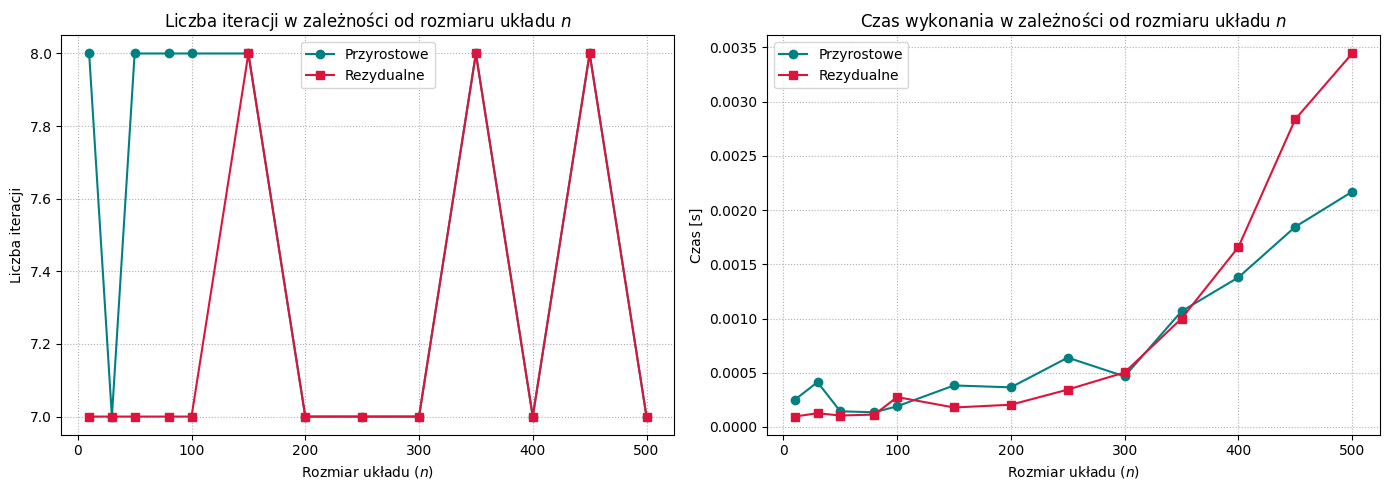

In [38]:
# Upewniamy się, że katalog na wykresy istnieje
os.makedirs('output/plots', exist_ok=True)

# Rozdzielenie danych na dwa kryteria
df_inc = df_exp1[df_exp1['Kryterium'] == 'przyrostowe']
df_res = df_exp1[df_exp1['Kryterium'] == 'rezydualne']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Liczba iteracji vs n
ax1.plot(df_inc['Rozmiar n'], df_inc['Liczba iteracji'], 'o-', label='Przyrostowe', color='teal')
ax1.plot(df_res['Rozmiar n'], df_res['Liczba iteracji'], 's-', label='Rezydualne', color='crimson')
ax1.set_title('Liczba iteracji w zależności od rozmiaru układu $n$')
ax1.set_xlabel('Rozmiar układu ($n$)')
ax1.set_ylabel('Liczba iteracji')
ax1.grid(True, linestyle=':')
ax1.legend()

# Wykres 2: Czas wykonania vs n
ax2.plot(df_inc['Rozmiar n'], df_inc['Czas [s]'], 'o-', label='Przyrostowe', color='teal')
ax2.plot(df_res['Rozmiar n'], df_res['Czas [s]'], 's-', label='Rezydualne', color='crimson')
ax2.set_title('Czas wykonania w zależności od rozmiaru układu $n$')
ax2.set_xlabel('Rozmiar układu ($n$)')
ax2.set_ylabel('Czas [s]')
ax2.grid(True, linestyle=':')
ax2.legend()

plt.tight_layout()

# Zapis wykresu do pliku w wysokiej rozdzielczości (dpi=300 idealne do druku/PDF)
plot_path = 'output/plots/experiment_1_plots.png'
plt.savefig(plot_path, dpi=300)
print(f"Wykresy zostały pomyślnie zapisane do: {plot_path}")

plt.show()

### Wykres 3: Eksperyment 2


Wykresy zostały pomyślnie zapisane do: output/plots/experiment_2_plots.png


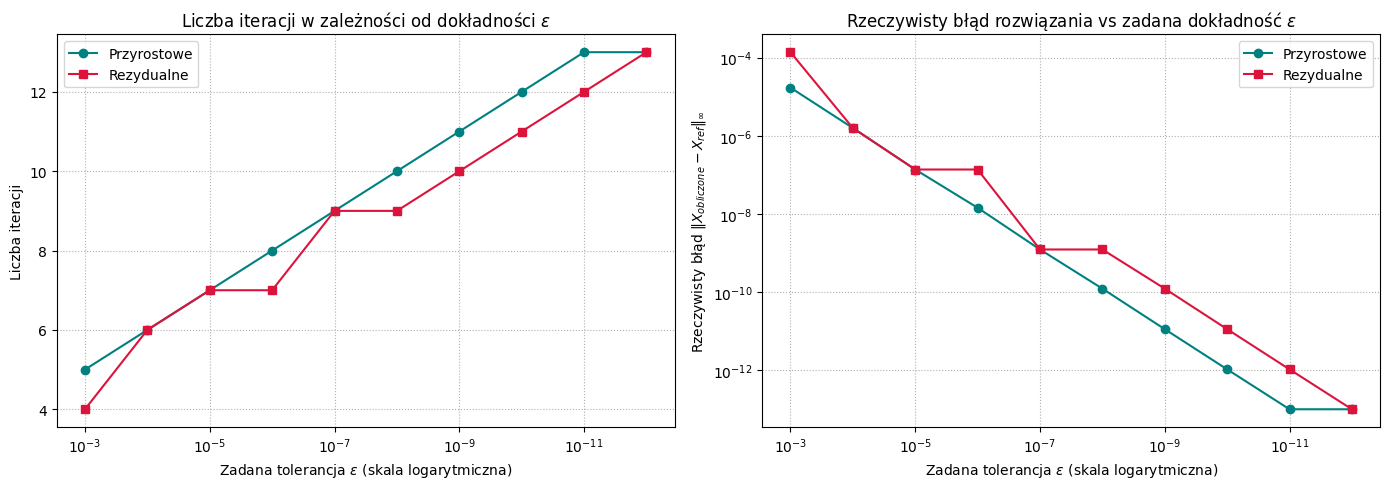

In [41]:
# Rozdzielenie danych na dwa kryteria
df_inc_e = df_exp2[df_exp2['Kryterium'] == 'przyrostowe']
df_res_e = df_exp2[df_exp2['Kryterium'] == 'rezydualne']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Liczba iteracji vs Epsilon (dodana literka 'r' przed tekstami z LaTeX)
ax1.plot(df_inc_e['Epsilon'], df_inc_e['Liczba iteracji'], 'o-', label='Przyrostowe', color='teal')
ax1.plot(df_res_e['Epsilon'], df_res_e['Liczba iteracji'], 's-', label='Rezydualne', color='crimson')
ax1.set_xscale('log')
ax1.invert_xaxis() 
ax1.set_title(r'Liczba iteracji w zależności od dokładności $\epsilon$')
ax1.set_xlabel(r'Zadana tolerancja $\epsilon$ (skala logarytmiczna)')
ax1.set_ylabel('Liczba iteracji')
ax1.grid(True, linestyle=':', which="both")
ax1.legend()

# Wykres 2: Rzeczywisty błąd vs Epsilon (dodana literka 'r' przed tekstami z LaTeX)
ax2.plot(df_inc_e['Epsilon'], df_inc_e['Błąd rzeczywisty'], 'o-', label='Przyrostowe', color='teal')
ax2.plot(df_res_e['Epsilon'], df_res_e['Błąd rzeczywisty'], 's-', label='Rezydualne', color='crimson')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.set_title(r'Rzeczywisty błąd rozwiązania vs zadana dokładność $\epsilon$')
ax2.set_xlabel(r'Zadana tolerancja $\epsilon$ (skala logarytmiczna)')
ax2.set_ylabel(r'Rzeczywisty błąd $\|X_{obliczone} - X_{ref}\|_\infty$')
ax2.grid(True, linestyle=':', which="both")
ax2.legend()

plt.tight_layout()

# Zapis wykresu do pliku
plot_path_exp2 = 'output/plots/experiment_2_plots.png'
plt.savefig(plot_path_exp2, dpi=300)
print(f"Wykresy zostały pomyślnie zapisane do: {plot_path_exp2}")

plt.show()